In [1]:
import numpy as np
from nanover.recording import NanoverRecordingReader
from nanover.utilities.state_dictionary import DictionaryChange
from nanover.imd.imd_state import dict_to_interaction
from follower import Checkpoint, Pin


IN_PATH = "knot-tying-checkpoints-3.nanover.zip"
RESTRAINT_PREFIX = "interaction.MOVEABLE-RESTRAINT"
CHECKPOINT_KEY = "mark.checkpoint"


CHECKPOINTS: list[Checkpoint] = []


with NanoverRecordingReader.from_path(IN_PATH) as reader:
    index: dict[str, set[int]] = {}

    for event in reader.iter_max():
        if event.next_state_event is None:
            continue

        change = DictionaryChange.from_dict(event.next_state_event.message)

        if CHECKPOINT_KEY not in change.updates:
            continue

        checkpoint = Checkpoint()
        positions = event.next_frame.particle_positions

        for key in event.next_state:
            if key.startswith(RESTRAINT_PREFIX):
                restraint = dict_to_interaction(event.next_state[key])
                particles = [int(i) for i in restraint.particles]
                centroid = np.average(positions[particles], axis=0)

                pin = Pin(particles=particles, position=centroid)
                checkpoint.pins.append(pin)

        if checkpoint.pins:
            CHECKPOINTS.append(checkpoint)

CHECKPOINTS

[Checkpoint(pins=[Pin(particles=[162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172], position=array([3.8089964, 4.998284 , 6.6852784], dtype=float32)), Pin(particles=[92, 93, 94, 95, 96, 97, 98, 99, 100, 101], position=array([4.2497435, 5.7474904, 4.203066 ], dtype=float32)), Pin(particles=[62, 63, 64, 65, 66, 67, 68, 69, 70, 71], position=array([4.269982 , 5.9217944, 3.0951018], dtype=float32)), Pin(particles=[32, 33, 34, 35, 36, 37, 38, 39, 40, 41], position=array([4.5023756, 4.7311482, 2.9572623], dtype=float32)), Pin(particles=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], position=array([4.405389 , 4.607946 , 4.1148925], dtype=float32))]),
 Checkpoint(pins=[Pin(particles=[92, 93, 94, 95, 96, 97, 98, 99, 100, 101], position=array([4.3857174, 5.837157 , 4.1985774], dtype=float32)), Pin(particles=[62, 63, 64, 65, 66, 67, 68, 69, 70, 71], position=array([4.2763863, 5.892229 , 3.0776446], dtype=float32)), Pin(particles=[32, 33, 34, 35, 36, 37, 38, 39, 40, 41], position=array([4.4687147, 4

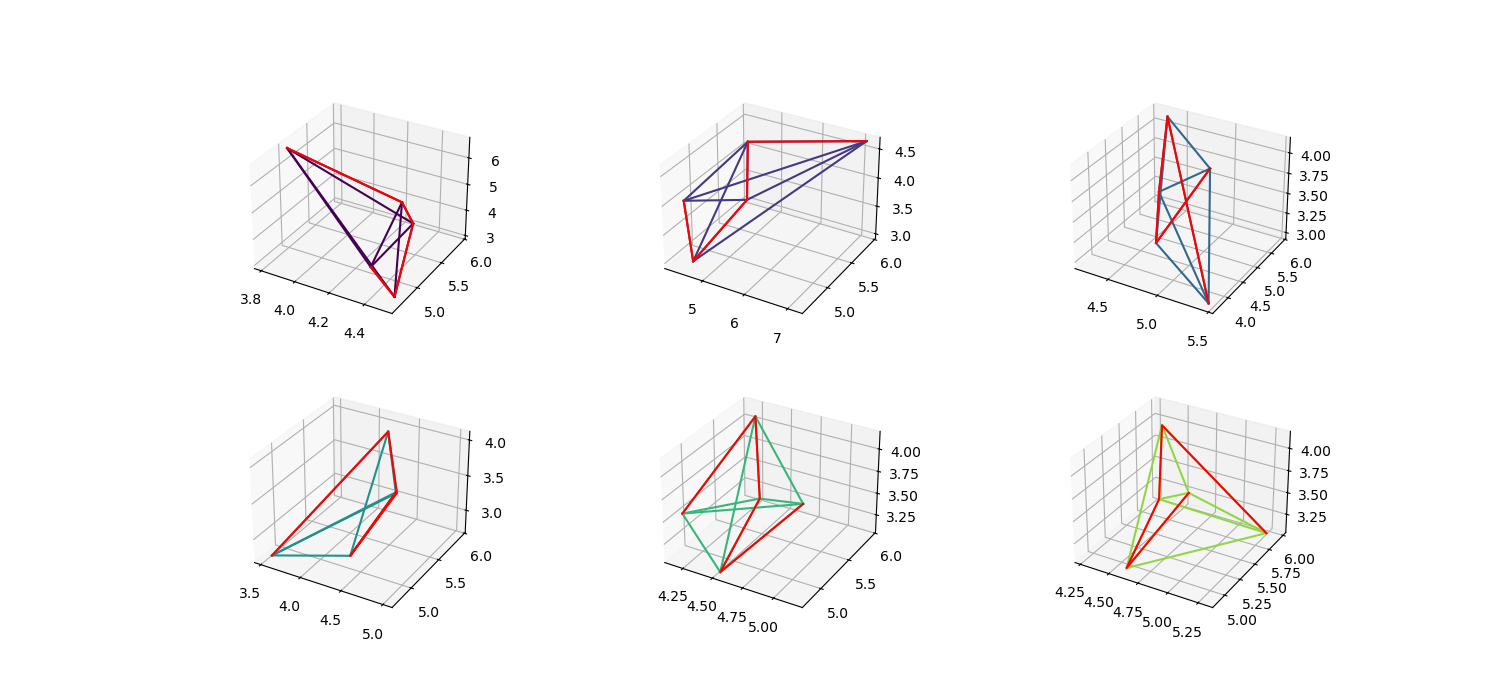

In [2]:
%matplotlib widget

from itertools import combinations
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, (len(CHECKPOINTS)+1)//2, subplot_kw=dict(projection='3d'), figsize=(15, 7))
cmap = plt.get_cmap()

checkpoint = CHECKPOINTS[0]

for i, checkpoint in enumerate(CHECKPOINTS):
    ax = axs.flatten()[i]

    checkpoint.pins.sort(key=lambda pin: pin.particles[0])

    positions = [pin.position for pin in checkpoint.pins]
    pairs = list(combinations(positions, 2))

    for pair in pairs:
        points = np.array(pair)
        X, Y, Z = points[:, 0], points[:, 1], points[:, 2]
        ax.plot(X, Y, Z, color=cmap(i/len(CHECKPOINTS)))

    points = np.array(positions)
    X, Y, Z = points[:, 0], points[:, 1], points[:, 2]
    ax.plot(X, Y, Z, color="red")

#plt.legend()
plt.show()

In [3]:
## Setup runner
from nanover.app import OmniRunner
from nanover.openmm import OpenMMSimulation

simulation = OpenMMSimulation.from_xml_path("../openmm/openmm_files/17-ala.xml")
simulation.load()

imd_runner = OmniRunner.with_basic_server(simulation, port=0, name="checkpoint replay")
imd_runner.load(0)

In [4]:
simulation.use_pbc_wrapping = False

In [5]:
from nanover.websocket import NanoverImdClient

client = NanoverImdClient.from_runner(imd_runner)
with client.root_selection.modify() as selection:
    selection.renderer = "cartoon"

In [6]:
def notify_all(message):
    for command in imd_runner.app_server.commands:
        if "/notify" in command:
            imd_runner.app_server.run_command(command, dict(message=message))

In [7]:
from follower import Follower, Group, Path, DistanceFollower

CHECKPOINT_INDEX = 0
FOLLOWER: Follower | None = None


def get_current_centroid(particles: list[int]):
    frame = imd_runner.app_server.frame_publisher.current_frame
    centroid = np.average(frame.particle_positions[particles], axis=0)
    return centroid


def replay_start():
    global FOLLOWER, CHECKPOINT_INDEX

    notify_all(f"REPLAYING CHECKPOINT {CHECKPOINT_INDEX}")

    checkpoint = CHECKPOINTS[CHECKPOINT_INDEX]
    CHECKPOINT_INDEX += 1

    groups = [
        Group(particles=pin.particles, path=Path.from_points([get_current_centroid(pin.particles), pin.position]))
        for pin in checkpoint.pins
    ]

    if FOLLOWER is not None:
        FOLLOWER.stop()

    FOLLOWER = Follower.from_runner(imd_runner)
    FOLLOWER.start(groups, release=False, speed=0.05)


def replay_start_distance():
    global FOLLOWER, CHECKPOINT_INDEX

    notify_all(f"REPLAYING CHECKPOINT {CHECKPOINT_INDEX}")

    checkpoint = CHECKPOINTS[CHECKPOINT_INDEX]
    CHECKPOINT_INDEX += 1

    if FOLLOWER is not None:
        FOLLOWER.stop()

    FOLLOWER = DistanceFollower.from_runner(imd_runner)
    FOLLOWER.start(checkpoint, speed=0.2, output=output)


def replay_cancel():
    global FOLLOWER, CHECKPOINT_INDEX
    FOLLOWER.stop()
    FOLLOWER = None
    CHECKPOINT_INDEX = 0

    notify_all(f"RESETING REPLAY")


imd_runner.app_server.register_command("user/replay/start", replay_start_distance)
# imd_runner.app_server.register_command("user/replay/start", replay_start)
imd_runner.app_server.register_command("user/replay/cancel", replay_cancel)

In [8]:
from ipywidgets import Output
output = Output()
output

Output()

In [9]:
with output:
    print("test")

In [10]:
# replay_start_distance()